In [2]:
import sys
sys.path.insert(0, "/global/homes/l/lettieri/gcr-catalogs")
sys.path.insert(0, "../match_by_proximity")
sys.path.insert(0, "../")

from astropy.io import fits
from astropy.table import unique, Table
from GCR import GCRQuery
import GCRCatalogs
from generate_mock import generate_halo_cluster, HOD_model, generate_halo_galaxies, generate_cluster_galaxies, sharing_galaxies
from matplotlib import pyplot as plt
import numpy as np
from numcosmo_py import Ncm, Nc
from numcosmo_py.external.pyssc import pyssc as PySS
from numcosmo_py.helper import npa_to_seq
from numcosmo_py import sky_match
from numcosmo_py.plotting.tools import set_rc_params_article, confidence_ellipse
import pandas as pd
import time
from time_model import PySLineModel, PySLineGauss
from tqdm import tqdm
#set_rc_params_article(ncol=1)



plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",  # This tells Matplotlib to use Computer Modern for math
    "axes.labelweight": "normal"
})

print('GCRCatalogs =', GCRCatalogs.__version__, '|' ,'GCR =', GCRCatalogs.GCR.__version__)

Ncm.cfg_init()
%load_ext autoreload
%autoreload 2    

GCRCatalogs = 1.10.2 | GCR = 0.9.2


In [3]:
Omega_b = 0.0486
Omega_c = 0.2614
Omega_k = 0.0
H0 = 67.7

#Omega_b = 0.05
#Omega_c = 0.25
#Omega_k = 0.0
#H0 = 70.0

# Create a cosmology object
cosmo = Nc.HICosmoDEXcdm.new()
cosmo.omega_x2omega_k()
cosmo["Omegab"] = Omega_b
cosmo["Omegac"] = Omega_c
cosmo["Omegak"] = Omega_k
cosmo["H0"] = H0
cosmo["w"] = -1.0

dist = Nc.Distance.new(100.0)
dist.compute_inv_comoving(True)
dist.prepare(cosmo)

# ID match time test

## Size of query catalog

In [3]:
# Lets fix the numpy seed to get reproducible results
np.random.seed(74682)
halo_properties  = {"Mass":"halo_mass","halo_id":"halo_id", "R200":"R200"}
halo_member_properties  = {"halo_mass":"halo_mass","halo_id":"halo_id", "galaxy_id":"galaxy_id"}
cluster_properties  = {"Mass":"cluster_mass","cluster_id":"cluster_id", "R200":"R200"}
cluster_member_properties  = {"cluster_mass":"cluster_mass","cluster_id":"cluster_id", "galaxy_id":"galaxy_id"}



halo_sizes = [150000,200000]
mean_time_halo_m = []
mean_time_halo_b = []
mean_time_halo = []
std_time_halo_m  = []
std_time_halo_b  = []
std_time_halo = []
size_halo = []
for halo_size in halo_sizes:

    halos, clusters = generate_halo_cluster(cosmo,dist,halo_size,100)
    halo_galaxies = generate_halo_galaxies(halos, cosmo,dist)
    cluster_galaxies = generate_cluster_galaxies(clusters, cosmo,dist)
    halo_galaxies_shared = sharing_galaxies(halos,halo_galaxies,cluster_galaxies, cosmo, halo_properties, cluster_member_properties, "halo")
    cluster_galaxies_shared = sharing_galaxies(clusters,cluster_galaxies,halo_galaxies, cosmo, cluster_properties, halo_member_properties, "cluster")
    print("Mock data generated")
    
    size_halo.append(halo_size)

    halo_coordinates = {"RA":"RA" , "DEC":"DEC" , "z":"z"}
    halo_ids  = {"ID": "halo_id", "MemberID": "galaxy_id"}

    detections_coordinates =  {"RA":"RA" , "DEC":"DEC" , "z":"z"}
    detections_ids  = {"ID": "cluster_id", "MemberID": "galaxy_id"}


    halos_m = sky_match.SkyMatch(
    query_data= halos,
    query_coordinates=halo_coordinates,
    query_member_data=halo_galaxies_shared,
    query_ids = halo_ids, 
    match_data=clusters,
    match_coordinates=detections_coordinates,
    match_member_data=cluster_galaxies,
    match_ids = detections_ids
)

    time_match_m, time_match_b, time_match = [], [], []
    for i in range(5):
        start = time.perf_counter()
        
        # Match phase
        start_m = time.perf_counter()
        halos_matched = halos_m.match_ID()
        end_m = time.perf_counter()        
        time_match_m.append(end_m - start_m) 

        # Best selection phase
        start_b = time.perf_counter()
        best_halos = halos_matched.select_best()
        end_b = time.perf_counter()       
        time_match_b.append(end_b - start_b)
        
        end = time.perf_counter()
        time_match.append(end - start)

    time_match_m = np.array(time_match_m)
    time_match_b = np.array(time_match_b)
    time_match   = np.array(time_match)
    
    mean_time_halo_m.append(np.mean(time_match_m))
    std_time_halo_m.append(np.std(time_match_m))

    mean_time_halo_b.append(np.mean(time_match_b))
    std_time_halo_b.append(np.std(time_match_b))

    mean_time_halo.append(np.mean(time_match))
    std_time_halo.append(np.std(time_match))

mean_time_halo_m = np.array(mean_time_halo_m)
std_time_halo_m = np.array(std_time_halo_m)

mean_time_halo_b = np.array(mean_time_halo_b)
std_time_halo_b = np.array(std_time_halo_b)


mean_time_halo = np.array(mean_time_halo)
std_time_halo = np.array(std_time_halo)

size_halo = np.array(size_halo)

slm = PySLineModel()
slm.props.alpha = 0.9
slm.props.a = 0.2


mset = Ncm.MSet.empty_new()
mset.set(slm)
mset.param_set_all_ftype(Ncm.ParamType.FREE)
mset.prepare_fparam_map()

cov = Ncm.Matrix.new(len(mean_time_halo), len(mean_time_halo))
cov.set_zero()
cov.set_diag(Ncm.Vector.new_array(npa_to_seq(np.array(std_time_halo))))

sld = PySLineGauss()
sld.set_size(len(mean_time_halo))
sld.set_init(True)
sld.use_norma(False)

sld.xv = Ncm.Vector.new_array(npa_to_seq(size_halo/1e6))
sld.set_cov(cov)
sld.peek_mean().set_array(npa_to_seq(mean_time_halo))


dset = Ncm.Dataset.new()
dset.append_data(sld)
lh = Ncm.Likelihood.new(dset)

fit = Ncm.Fit.factory(Ncm.FitType.NLOPT, "ln-neldermead", lh, mset, Ncm.FitGradType.NUMDIFF_FORWARD)
fit.run(Ncm.FitRunMsgs.FULL)
fit.log_info()
fit.obs_fisher()
fit.log_covar()

def bf_plot(x):
    return 1*(slm.props.alpha * x + slm.props.a)
x_v= np.linspace(0 , 1, 1000)
# Capture the line object
plt.figure(figsize=set_size(440, 0.45))
# Get the color from that line and apply it to errorbar
line, = plt.plot(x_v, bf_plot(x_v),linestyle="--",color='orange',label="best-fit")
plt.errorbar(size_halo/1e6, mean_time_halo, yerr=2*std_time_halo, fmt='o', markersize=4, 
              color=line.get_color(),markeredgecolor="black",ecolor="black", capsize=3,label="Time measure")

plt.legend()
plt.ylabel("Time(s)")
plt.xlabel(r"N query objects ($10^6$)")
plt.ylim(0, 1.8)
plt.xlim(0, 0.25)
plt.grid(True)
plt.xticks(fontsize=12) 
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.locator_params(axis='y', nbins=5)
plt.tight_layout()
plt.savefig("plot_time_x_nobjects_query_id.pdf")
plt.show()

Generated 566 galaxies from 200 halos.
Generated 464 galaxies from 100 clusters.
Mock data generated
Generated 866 galaxies from 500 halos.
Generated 464 galaxies from 100 clusters.
Mock data generated
Generated 1369 galaxies from 1000 halos.
Generated 464 galaxies from 100 clusters.
Mock data generated
Generated 2369 galaxies from 2000 halos.
Generated 464 galaxies from 100 clusters.
Mock data generated
Generated 5371 galaxies from 5000 halos.
Generated 464 galaxies from 100 clusters.
Mock data generated
Generated 7877 galaxies from 7500 halos.
Generated 464 galaxies from 100 clusters.
Mock data generated
Generated 10379 galaxies from 10000 halos.
Generated 464 galaxies from 100 clusters.
Mock data generated
Generated 20392 galaxies from 20000 halos.
Generated 464 galaxies from 100 clusters.
Mock data generated
Generated 50460 galaxies from 50000 halos.
Generated 464 galaxies from 100 clusters.
Mock data generated
Generated 100530 galaxies from 100000 halos.
Generated 464 galaxies fro

NameError: name 'set_size' is not defined

## Size of match catalog

Generated 401196 galaxies from 400000 halos.
Generated 824 galaxies from 200 clusters.
Mock data generated
Generated 402296 galaxies from 400000 halos.
Generated 2010 galaxies from 500 clusters.
Mock data generated
Generated 404038 galaxies from 400000 halos.
Generated 4355 galaxies from 1000 clusters.
Mock data generated
Generated 407162 galaxies from 400000 halos.
Generated 8160 galaxies from 2000 clusters.
Mock data generated
Generated 416715 galaxies from 400000 halos.
Generated 20428 galaxies from 5000 clusters.
Mock data generated
Generated 425039 galaxies from 400000 halos.
Generated 31338 galaxies from 7500 clusters.
Mock data generated
Generated 431562 galaxies from 400000 halos.
Generated 40312 galaxies from 10000 clusters.
Mock data generated
Generated 465012 galaxies from 400000 halos.
Generated 83063 galaxies from 20000 clusters.
Mock data generated
Generated 562856 galaxies from 400000 halos.
Generated 206070 galaxies from 50000 clusters.
Mock data generated
Generated 723

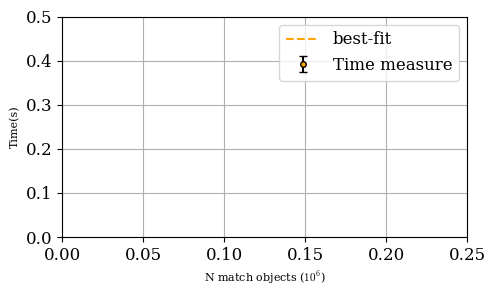

In [19]:
# Lets fix the numpy seed to get reproducible results
np.random.seed(74682)
halo_properties  = {"Mass":"halo_mass","halo_id":"halo_id", "R200":"R200"}
halo_member_properties  = {"halo_mass":"halo_mass","halo_id":"halo_id", "galaxy_id":"galaxy_id"}
cluster_properties  = {"Mass":"cluster_mass","cluster_id":"cluster_id", "R200":"R200"}
cluster_member_properties  = {"cluster_mass":"cluster_mass","cluster_id":"cluster_id", "galaxy_id":"galaxy_id"}



cluster_sizes = [200,500,1000,2000,5000,7500, 10000,20000,50000,100000,150000,200000]
mean_time_halo_m = []
mean_time_halo_b = []
mean_time_halo = []
std_time_halo_m  = []
std_time_halo_b  = []
std_time_halo = []
size_halo = []
for cluster_size in cluster_sizes:

    halos, clusters = generate_halo_cluster(cosmo,dist,2*cluster_sizes[-1],cluster_size)
    halo_galaxies = generate_halo_galaxies(halos, cosmo,dist)
    cluster_galaxies = generate_cluster_galaxies(clusters, cosmo,dist)
    halo_galaxies_shared = sharing_galaxies(halos,halo_galaxies,cluster_galaxies, cosmo, halo_properties, cluster_member_properties, "halo")
    cluster_galaxies_shared = sharing_galaxies(clusters,cluster_galaxies,halo_galaxies, cosmo, cluster_properties, halo_member_properties, "cluster")
    print("Mock data generated")
    
    size_halo.append(cluster_size)

    halo_coordinates = {"RA":"RA" , "DEC":"DEC" , "z":"z"}
    halo_ids  = {"ID": "halo_id", "MemberID": "galaxy_id"}

    detections_coordinates =  {"RA":"RA" , "DEC":"DEC" , "z":"z"}
    detections_ids  = {"ID": "cluster_id", "MemberID": "galaxy_id"}


    halos_m = sky_match.SkyMatch(
    query_data= halos,
    query_coordinates=halo_coordinates,
    query_member_data=halo_galaxies_shared,
    query_ids = halo_ids, 
    match_data=clusters,
    match_coordinates=detections_coordinates,
    match_member_data=cluster_galaxies,
    match_ids = detections_ids
)

    time_match_m, time_match_b, time_match = [], [], []
    for i in range(5):
        start = time.perf_counter()
        
        # Match phase
        start_m = time.perf_counter()
        halos_matched = halos_m.match_ID()
        end_m = time.perf_counter()        
        time_match_m.append(end_m - start_m) 

        # Best selection phase
        start_b = time.perf_counter()
        best_halos = halos_matched.select_best()
        end_b = time.perf_counter()       
        time_match_b.append(end_b - start_b)
        
        end = time.perf_counter()
        time_match.append(end - start)

    time_match_m = np.array(time_match_m)
    time_match_b = np.array(time_match_b)
    time_match   = np.array(time_match)
    
    mean_time_halo_m.append(np.mean(time_match_m))
    std_time_halo_m.append(np.std(time_match_m))

    mean_time_halo_b.append(np.mean(time_match_b))
    std_time_halo_b.append(np.std(time_match_b))

    mean_time_halo.append(np.mean(time_match))
    std_time_halo.append(np.std(time_match))

mean_time_halo_m = np.array(mean_time_halo_m)
std_time_halo_m = np.array(std_time_halo_m)

mean_time_halo_b = np.array(mean_time_halo_b)
std_time_halo_b = np.array(std_time_halo_b)


mean_time_halo = np.array(mean_time_halo)
std_time_halo = np.array(std_time_halo)

size_halo = np.array(size_halo)

slm = PySLineModel()
slm.props.alpha = 0.9
slm.props.a = 0.2


mset = Ncm.MSet.empty_new()
mset.set(slm)
mset.param_set_all_ftype(Ncm.ParamType.FREE)
mset.prepare_fparam_map()

cov = Ncm.Matrix.new(len(mean_time_halo), len(mean_time_halo))
cov.set_zero()
cov.set_diag(Ncm.Vector.new_array(npa_to_seq(np.array(std_time_halo))))

sld = PySLineGauss()
sld.set_size(len(mean_time_halo))
sld.set_init(True)
sld.use_norma(False)

sld.xv = Ncm.Vector.new_array(npa_to_seq(size_halo/1e6))
sld.set_cov(cov)
sld.peek_mean().set_array(npa_to_seq(mean_time_halo/100))


dset = Ncm.Dataset.new()
dset.append_data(sld)
lh = Ncm.Likelihood.new(dset)

fit = Ncm.Fit.factory(Ncm.FitType.NLOPT, "ln-neldermead", lh, mset, Ncm.FitGradType.NUMDIFF_FORWARD)
fit.run(Ncm.FitRunMsgs.FULL)
fit.log_info()
fit.obs_fisher()
fit.log_covar()

def bf_plot(x):
    return 100*(slm.props.alpha * x + slm.props.a)
x_v= np.linspace(0 , 1, 1000)
# Capture the line object

# Get the color from that line and apply it to errorbar

plt.figure(figsize=(5,3))
line, = plt.plot(x_v, bf_plot(x_v),linestyle="--",color='orange',label="best-fit")
plt.errorbar(size_halo/1e6, mean_time_halo, yerr=2*std_time_halo, fmt='o', markersize=4, 
              color=line.get_color(),markeredgecolor="black",ecolor="black", capsize=3,label="Time measure")

plt.legend()
plt.ylabel("Time(s)")
plt.xlabel(r"N match objects ($10^6$)")
plt.ylim(0, 0.5)
plt.xlim(0, 0.25)
plt.grid(True)
plt.xticks(fontsize=12) 
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.locator_params(axis='y', nbins=5)
plt.tight_layout()
plt.savefig("plot_time_x_nobjects_match_id.pdf")
plt.show()

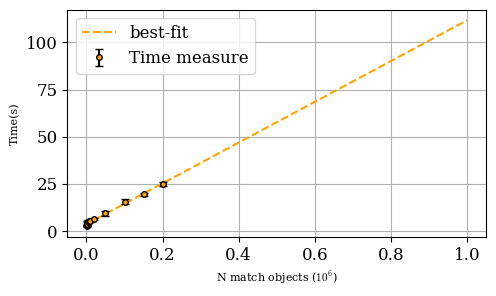

In [20]:
plt.figure(figsize=(5,3))
line, = plt.plot(x_v, bf_plot(x_v),linestyle="--",color='orange',label="best-fit")
plt.errorbar(size_halo/1e6, mean_time_halo, yerr=2*std_time_halo, fmt='o', markersize=4, 
              color=line.get_color(),markeredgecolor="black",ecolor="black", capsize=3,label="Time measure")

plt.legend()
plt.ylabel("Time(s)")
plt.xlabel(r"N match objects ($10^6$)")
#plt.ylim(0, 0.5)
#plt.xlim(0, 0.25)
plt.grid(True)
plt.xticks(fontsize=12) 
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.locator_params(axis='y', nbins=5)
plt.tight_layout()
plt.savefig("plot_time_x_nobjects_match_id.pdf")
plt.show()

## Both sizes

Generated 1007 galaxies from 400 halos.
Generated 824 galaxies from 200 clusters.
Mock data generated
Generated 2680 galaxies from 1000 halos.
Generated 2010 galaxies from 500 clusters.
Mock data generated
Generated 5439 galaxies from 2000 halos.
Generated 4355 galaxies from 1000 clusters.
Mock data generated
Generated 10559 galaxies from 4000 halos.
Generated 8160 galaxies from 2000 clusters.
Mock data generated
Generated 26104 galaxies from 10000 halos.
Generated 20428 galaxies from 5000 clusters.
Mock data generated
Generated 39415 galaxies from 15000 halos.
Generated 31338 galaxies from 7500 clusters.
Mock data generated
Generated 50993 galaxies from 20000 halos.
Generated 40312 galaxies from 10000 clusters.
Mock data generated
Generated 104433 galaxies from 40000 halos.
Generated 83063 galaxies from 20000 clusters.
Mock data generated
Generated 262365 galaxies from 100000 halos.
Generated 206070 galaxies from 50000 clusters.
Mock data generated
Generated 523187 galaxies from 20000

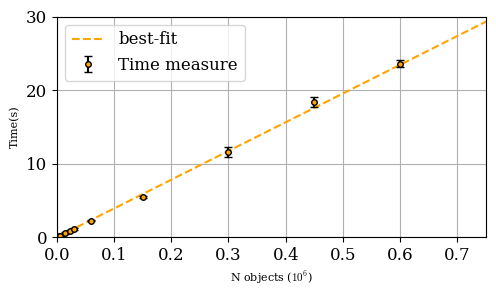

In [5]:
# Lets fix the numpy seed to get reproducible results
np.random.seed(74682)
halo_properties  = {"Mass":"halo_mass","halo_id":"halo_id", "R200":"R200"}
halo_member_properties  = {"halo_mass":"halo_mass","halo_id":"halo_id", "galaxy_id":"galaxy_id"}
cluster_properties  = {"Mass":"cluster_mass","cluster_id":"cluster_id", "R200":"R200"}
cluster_member_properties  = {"cluster_mass":"cluster_mass","cluster_id":"cluster_id", "galaxy_id":"galaxy_id"}



cluster_sizes = [200,500,1000,2000,5000,7500, 10000,20000,50000,100000,150000,200000]
mean_time_halo_m = []
mean_time_halo_b = []
mean_time_halo = []
std_time_halo_m  = []
std_time_halo_b  = []
std_time_halo = []
size_halo = []
for cluster_size in cluster_sizes:

    halos, clusters = generate_halo_cluster(cosmo,dist,2*cluster_size,cluster_size)
    halo_galaxies = generate_halo_galaxies(halos, cosmo,dist)
    cluster_galaxies = generate_cluster_galaxies(clusters, cosmo,dist)
    halo_galaxies_shared = sharing_galaxies(halos,halo_galaxies,cluster_galaxies, cosmo, halo_properties, cluster_member_properties, "halo")
    cluster_galaxies_shared = sharing_galaxies(clusters,cluster_galaxies,halo_galaxies, cosmo, cluster_properties, halo_member_properties, "cluster")
    print("Mock data generated")
    
    size_halo.append(cluster_size + 2*cluster_size)

    halo_coordinates = {"RA":"RA" , "DEC":"DEC" , "z":"z"}
    halo_ids  = {"ID": "halo_id", "MemberID": "galaxy_id"}

    detections_coordinates =  {"RA":"RA" , "DEC":"DEC" , "z":"z"}
    detections_ids  = {"ID": "cluster_id", "MemberID": "galaxy_id"}


    halos_m = sky_match.SkyMatch(
    query_data= halos,
    query_coordinates=halo_coordinates,
    query_member_data=halo_galaxies_shared,
    query_ids = halo_ids, 
    match_data=clusters,
    match_coordinates=detections_coordinates,
    match_member_data=cluster_galaxies,
    match_ids = detections_ids
)

    time_match_m, time_match_b, time_match = [], [], []
    for i in range(5):
        start = time.perf_counter()
        
        # Match phase
        start_m = time.perf_counter()
        halos_matched = halos_m.match_ID()
        end_m = time.perf_counter()        
        time_match_m.append(end_m - start_m) 

        # Best selection phase
        start_b = time.perf_counter()
        best_halos = halos_matched.select_best()
        end_b = time.perf_counter()       
        time_match_b.append(end_b - start_b)
        
        end = time.perf_counter()
        time_match.append(end - start)

    time_match_m = np.array(time_match_m)
    time_match_b = np.array(time_match_b)
    time_match   = np.array(time_match)
    
    mean_time_halo_m.append(np.mean(time_match_m))
    std_time_halo_m.append(np.std(time_match_m))

    mean_time_halo_b.append(np.mean(time_match_b))
    std_time_halo_b.append(np.std(time_match_b))

    mean_time_halo.append(np.mean(time_match))
    std_time_halo.append(np.std(time_match))

mean_time_halo_m = np.array(mean_time_halo_m)
std_time_halo_m = np.array(std_time_halo_m)

mean_time_halo_b = np.array(mean_time_halo_b)
std_time_halo_b = np.array(std_time_halo_b)


mean_time_halo = np.array(mean_time_halo)
std_time_halo = np.array(std_time_halo)

size_halo = np.array(size_halo)

slm = PySLineModel()
slm.props.alpha = 0.9
slm.props.a = 0.2


mset = Ncm.MSet.empty_new()
mset.set(slm)
mset.param_set_all_ftype(Ncm.ParamType.FREE)
mset.prepare_fparam_map()

cov = Ncm.Matrix.new(len(mean_time_halo), len(mean_time_halo))
cov.set_zero()
cov.set_diag(Ncm.Vector.new_array(npa_to_seq(np.array(std_time_halo))))

sld = PySLineGauss()
sld.set_size(len(mean_time_halo))
sld.set_init(True)
sld.use_norma(False)

sld.xv = Ncm.Vector.new_array(npa_to_seq(size_halo/1e6))
sld.set_cov(cov)
sld.peek_mean().set_array(npa_to_seq(mean_time_halo/100))


dset = Ncm.Dataset.new()
dset.append_data(sld)
lh = Ncm.Likelihood.new(dset)

fit = Ncm.Fit.factory(Ncm.FitType.NLOPT, "ln-neldermead", lh, mset, Ncm.FitGradType.NUMDIFF_FORWARD)
fit.run(Ncm.FitRunMsgs.FULL)
fit.log_info()
fit.obs_fisher()
fit.log_covar()

def bf_plot(x):
    return 100*(slm.props.alpha * x + slm.props.a)
x_v= np.linspace(0 , 1, 1000)
# Capture the line object

plt.figure(figsize=(5,3))
line, = plt.plot(x_v, bf_plot(x_v),linestyle="--",color='orange',label="best-fit")
plt.errorbar(size_halo/1e6, mean_time_halo, yerr=2*std_time_halo, fmt='o', markersize=4, 
              color=line.get_color(),markeredgecolor="black",ecolor="black", capsize=3,label="Time measure")

plt.legend()
plt.ylabel("Time(s)")
plt.xlabel(r"N objects ($10^6$)")
plt.ylim(0, 30)
plt.xlim(0, 0.75)
plt.grid(True)
plt.xticks(fontsize=12) 
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.locator_params(axis='y', nbins=5)
plt.tight_layout()
plt.savefig("plot_time_x_nobjects_both_id.pdf")
plt.show()